# Multiple Linear Regression: Salary Prediction

## Problem
Predict annual salary (in INR) using **several** inputs together: experience, education and skills.

## Objective
See how combining several features improves predictions compared with experience alone, and understand what each feature contributes.

**Dataset:** `data/salary_data.csv` (300 rows). The data is **synthetic** (randomly generated with a fixed seed by `data/generate_data.py`) for learning purposes. It does not describe real people.

| Column | Meaning |
|--------|---------|
| `years_experience` | Years of work experience |
| `education_level` | 1 = Bachelor, 2 = Master, 3 = PhD |
| `skills_score` | Skills assessment score from 0 to 100 |
| `salary` | Annual salary in INR (target) |

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Load the Dataset

In [2]:
from pathlib import Path

def find_data(filename):
    """Find data/<filename> by searching this notebook's folder and its parent folders."""
    here = Path.cwd().resolve()
    for folder in [here, *here.parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find data/{filename}. Open this notebook from inside the project folder."
    )


In [3]:
df = pd.read_csv(find_data("salary_data.csv"))
print("Shape:", df.shape, "| Missing values:", df.isna().sum().sum())
df.head()

Shape: (300, 4) | Missing values: 0


,years_experience,education_level,skills_score,salary
0,11.6,2,79,881700
1,6.6,1,56,645400
2,12.9,2,65,886000
3,10.5,2,24,772100
4,1.4,3,43,549900


## 3. Check How Features Relate (Correlation)

Two things matter:
1. Each feature should relate to **salary**.
2. Features should **not be copies of each other** (this problem is called *multicollinearity* and makes the coefficients unreliable).

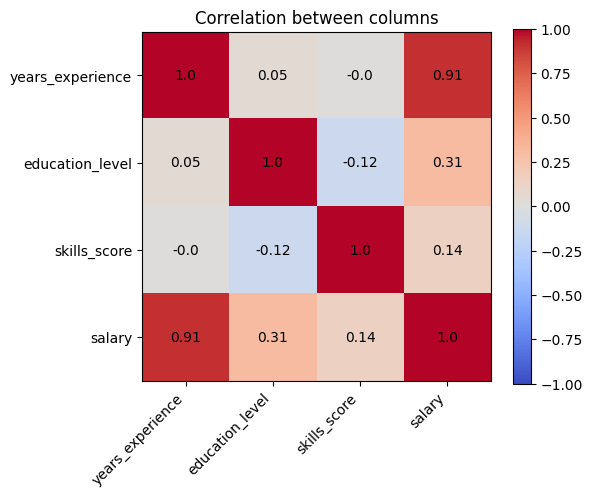

In [4]:
corr = df.corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center")
fig.colorbar(im)
ax.set_title("Correlation between columns")
plt.tight_layout()
plt.show()

Experience is strongly linked to salary (0.91), education is moderately linked (0.31), and the three input features are almost uncorrelated with each other. That is exactly what we want.

## 4. Define X and y, then Split into Train and Test

In [5]:
features = ["years_experience", "education_level", "skills_score"]
X = df[features]
y = df["salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", len(X_train), "| Test rows:", len(X_test))

Training rows: 240 | Test rows: 60


## 5. Train the Model

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.DataFrame({"feature": features, "coefficient": model.coef_.round(0)})
print(f"Intercept: Rs. {model.intercept_:,.0f}")
coefficients

Intercept: Rs. 232,201


,feature,coefficient
0,years_experience,32628.0
1,education_level,65736.0
2,skills_score,1854.0


**How to read the coefficients** (each one holds the other features fixed):

- `years_experience`: one more year adds about **Rs. 32,600**.
- `education_level`: one level higher (for example Bachelor to Master) adds about **Rs. 65,700**.
- `skills_score`: one more skill point adds about **Rs. 1,850**.

Because the features use different units, the coefficients are not directly comparable by size.

## 6. Evaluate the Model

In [7]:
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print(f"Train R2 : {r2_score(y_train, pred_train):.3f}")
print(f"Test  R2 : {r2_score(y_test, pred_test):.3f}")
print(f"Test  MAE : Rs. {mean_absolute_error(y_test, pred_test):,.0f}")
print(f"Test  RMSE: Rs. {np.sqrt(mean_squared_error(y_test, pred_test)):,.0f}")

Train R2 : 0.937
Test  R2 : 0.928
Test  MAE : Rs. 34,269
Test  RMSE: Rs. 41,636


### Does adding more features really help?

We compare against the simple model that uses **only experience**, on the same test rows.

In [8]:
simple = LinearRegression().fit(X_train[["years_experience"]], y_train)
simple_pred = simple.predict(X_test[["years_experience"]])

comparison = pd.DataFrame({
    "Model": ["Experience only", "Experience + Education + Skills"],
    "Test R2": [r2_score(y_test, simple_pred), r2_score(y_test, pred_test)],
    "Test MAE (Rs.)": [mean_absolute_error(y_test, simple_pred), mean_absolute_error(y_test, pred_test)],
}).round(3)
comparison

,Model,Test R2,Test MAE (Rs.)
0,Experience only,0.853,49731.443
1,Experience + Education + Skills,0.928,34268.742


## 7. Actual vs Predicted

If the model were perfect, every point would sit on the red diagonal line.

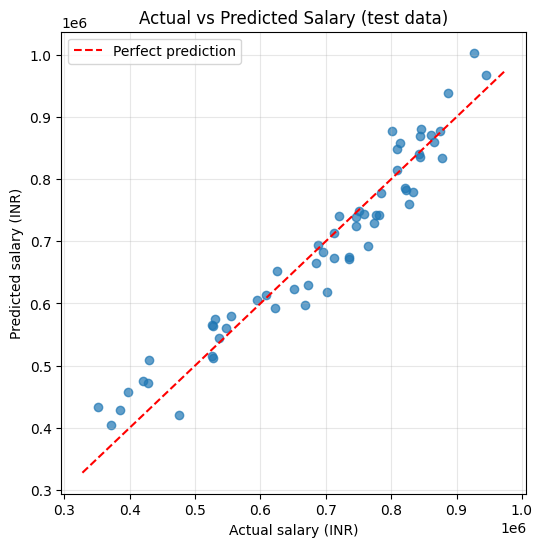

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_test, alpha=0.7)
low, high = y.min(), y.max()
plt.plot([low, high], [low, high], color="red", linestyle="--", label="Perfect prediction")
plt.title("Actual vs Predicted Salary (test data)")
plt.xlabel("Actual salary (INR)")
plt.ylabel("Predicted salary (INR)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Predict for a New Person

In [10]:
new_person = pd.DataFrame([[5, 2, 70]], columns=features)   # 5 years, Master's degree, skills score 70
print(f"Predicted salary: Rs. {model.predict(new_person)[0]:,.0f}")

Predicted salary: Rs. 656,601


## Conclusion

- Using three features raises test **R² from 0.85 to 0.93** and cuts the average error from about Rs. 49,700 to **Rs. 34,300**.
- Experience is the strongest driver, but education adds a clear premium of about Rs. 65,700 per level.
- The features are not copies of each other, so the coefficients can be interpreted.
- Train R² (0.94) and test R² (0.93) are close, so there is no sign of overfitting.
- The remaining error comes from random variation that these three features cannot explain.